# 11 — PEST with CalSim: HEC-DSS Integration

CalSim (DWR's statewide planning model) writes its results to **HEC-DSS**
files. Coupled IWFM–CalSim studies calibrate IWFM stream flows against
CalSim channel arcs — which means reading DSS, matching arcs to gauges,
and aligning the two models' time conventions. `iwfm_io.dss` covers all
of it:

- `dss_catalog` — every record in a DSS file as a DataFrame
- `read_dss_timeseries` — condensed-path reads with units metadata
- `link_calsim_channels` — gauge metadata → `C_*` channel arcs
- `calsim_streamflow_series` — extraction in CFS or TAF
- `cfs_to_taf` — month-length-aware unit conversion

**Requires:** `pip install iwfm-io[dss]` (pydsstools ≥ 3, which bundles
the HEC-DSS library; imported only at call time, so the rest of
`iwfm_io` never needs it).

There is no DSS file in the repo, so this notebook first **writes a
synthetic CalSim-style DV file** — which doubles as a demo of creating
DSS records from Python. Point the paths at a real `DV.dss` and every
cell below works unchanged.

In [1]:
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd

import pydsstools  # fail fast with a clear message if the extra is missing

WORK = Path(tempfile.mkdtemp(prefix="iwfm_nb11_"))
DSS_FILE = WORK / "DV.dss"

## Build a synthetic DV.dss

DSS pathnames have six parts `/A/B/C/D/E/F/`. CalSim convention:

- **A** = `CALSIM`, **B** = the arc (`C_SAC041` = channel, `D_*` =
  diversion, `S_*` = storage …), **C** = the data kind (`CHANNEL`),
- **D** = block start date, **E** = interval (`1MON`), **F** = study
  label (`L2020A`).

We write three channel arcs plus one diversion arc: 36 monthly
period-average flows in CFS, water years 1921–1923. `start_time=
"31JAN1921 2400"` stamps the January value at end-of-period — hour 2400,
exactly IWFM's `24:00` convention.

In [2]:
from pydsstools.core import TimeSeriesContainer
from pydsstools.heclib.dss.HecDss import Open

months = np.arange(36)
season = 1.0 + 0.8 * np.sin((months - 3) * 2 * np.pi / 12)  # spring peak

arcs = {
    "C_SAC041": 4000.0 * season,                    # big river
    "C_AMR004": 1200.0 * season + 50.0,             # tributary
    "C_MOK022": 300.0 * season + 20.0,              # small stream
    "D_SAC041": 250.0 + 100.0 * (season - 1.0),     # a diversion, not a channel
}

with Open(str(DSS_FILE)) as fid:
    for bpart, values in arcs.items():
        cpart = "CHANNEL" if bpart.startswith("C_") else "DIVERSION"
        tsc = TimeSeriesContainer(
            f"/CALSIM/{bpart}/{cpart}//1MON/L2020A/",
            len(values), 1, values=values.tolist(),
            start_time="31JAN1921 2400",
            data_units="CFS", data_type="PER-AVER")
        fid.put_ts(tsc)

print(f"wrote {DSS_FILE.name}: {len(arcs)} records x {len(months)} months")

wrote DV.dss: 4 records x 36 months


## Catalog the file

`dss_catalog` lists every record with its parts split out and a
**condensed** pathname (empty D part) — the form you read whole records
with, regardless of how many internal date blocks the file uses.

In [3]:
from iwfm_io import dss_catalog

cat = dss_catalog(DSS_FILE)
cat

,pathname,a,b,c,d,e,f,condensed
0,/CALSIM/C_AMR004/CHANNEL/01Jan1920/1Month/L2020A/,CALSIM,C_AMR004,CHANNEL,01Jan1920,1Month,L2020A,/CALSIM/C_AMR004/CHANNEL//1Month/L2020A/
1,/CALSIM/C_MOK022/CHANNEL/01Jan1920/1Month/L2020A/,CALSIM,C_MOK022,CHANNEL,01Jan1920,1Month,L2020A,/CALSIM/C_MOK022/CHANNEL//1Month/L2020A/
2,/CALSIM/C_SAC041/CHANNEL/01Jan1920/1Month/L2020A/,CALSIM,C_SAC041,CHANNEL,01Jan1920,1Month,L2020A,/CALSIM/C_SAC041/CHANNEL//1Month/L2020A/
3,/CALSIM/D_SAC041/DIVERSION/01Jan1920/1Month/L2...,CALSIM,D_SAC041,DIVERSION,01Jan1920,1Month,L2020A,/CALSIM/D_SAC041/DIVERSION//1Month/L2020A/


In [4]:
# a real CalSim DV file has thousands of records — filter with pandas
cat[cat["c"] == "CHANNEL"]["b"].tolist()

['C_AMR004', 'C_MOK022', 'C_SAC041']

## Read time series

`read_dss_timeseries` returns one column per condensed path, with units
and data-type metadata in `frame.attrs`.

**The time convention, once and for all:** DSS period data stamps each
value at *end of period* — the January 1921 average lands on
`1921-02-01 00:00`. IWFM's `24:00` convention produces exactly the same
instant, so CalSim monthly series and IWFM monthly output **align
directly, no shifting**.

In [5]:
from iwfm_io import read_dss_timeseries

paths = cat.loc[cat["c"] == "CHANNEL", "condensed"].unique().tolist()
flows_cfs = read_dss_timeseries(DSS_FILE, paths)
print("units:", set(flows_cfs.attrs["units"].values()),
      "| type:", set(flows_cfs.attrs["data_type"].values()))
print("first stamp:", flows_cfs.index[0], "(covers January 1921)")
flows_cfs.head(3)

units: {'CFS'} | type: {'PER-AVER'}
first stamp: 1921-02-01 00:00:00 (covers January 1921)


,/CALSIM/C_AMR004/CHANNEL//1Month/L2020A/,/CALSIM/C_MOK022/CHANNEL//1Month/L2020A/,/CALSIM/C_SAC041/CHANNEL//1Month/L2020A/
datetime,,,
1921-02-01,290.000000,80.0000,800.00000
1921-03-01,418.615601,112.1539,1228.71875
1921-04-01,770.000000,200.0000,2400.00000


## Unit conversion: `cfs_to_taf`

CalSim analysis is habitually in TAF (thousand acre-feet). Converting a
monthly *average* flow to a *volume* needs the number of days in the
month **the value covers** — which, with end-of-period stamps, is the
month *before* the stamp. `cfs_to_taf` handles that.

In [6]:
from iwfm_io import cfs_to_taf

flows_taf = cfs_to_taf(flows_cfs)
flows_taf.head(3)

,/CALSIM/C_AMR004/CHANNEL//1Month/L2020A/,/CALSIM/C_MOK022/CHANNEL//1Month/L2020A/,/CALSIM/C_SAC041/CHANNEL//1Month/L2020A/
datetime,,,
1921-02-01,17.831405,4.919008,49.190083
1921-03-01,23.248734,6.228712,68.239587
1921-04-01,47.345455,12.297521,147.570248


## Link gauges to CalSim arcs

The gauge metadata table from notebook 08 grows one column:
`calsim_bpart`. `link_calsim_channels` matches it (case-insensitively)
against the catalog's B parts, collapses multi-block records, restricts
to channel arcs, and reports orphans both ways. A `dss_path` column
overrides the match for special cases.

On real DV files pass `cpart="CHANNEL"` (and `fpart=` when several
studies share the file) — the same B part often appears under several
C parts.

In [7]:
from iwfm_io import link_calsim_channels

gauge_md = pd.DataFrame({
    "gauge_id": ["sac_at_41", "american_04", "mokelumne_22", "no_such"],
    "calsim_bpart": ["C_SAC041", "c_amr004", "C_MOK022", "C_NOPE01"],
})
link = link_calsim_channels(gauge_md, DSS_FILE, cpart="CHANNEL")
print(link.summary())
print("unmatched gauges:", link.unmatched_gauges)
link.links

{'n_gauges_linked': 3, 'n_unmatched_gauges': 1, 'n_orphan_arcs': 0}
unmatched gauges: ['no_such']


,gauge_id,bpart,pathname
0,sac_at_41,C_SAC041,/CALSIM/C_SAC041/CHANNEL//1Month/L2020A/
1,american_04,C_AMR004,/CALSIM/C_AMR004/CHANNEL//1Month/L2020A/
2,mokelumne_22,C_MOK022,/CALSIM/C_MOK022/CHANNEL//1Month/L2020A/


## Extract gauge flow series

In [8]:
from iwfm_io import calsim_streamflow_series

cfs = calsim_streamflow_series(link, DSS_FILE)            # as stored
taf = calsim_streamflow_series(link, DSS_FILE, units="taf")
taf.head(3)

,sac_at_41,american_04,mokelumne_22
datetime,,,
1921-02-01,49.190083,17.831405,4.919008
1921-03-01,68.239587,23.248734,6.228712
1921-04-01,147.570248,47.345455,12.297521


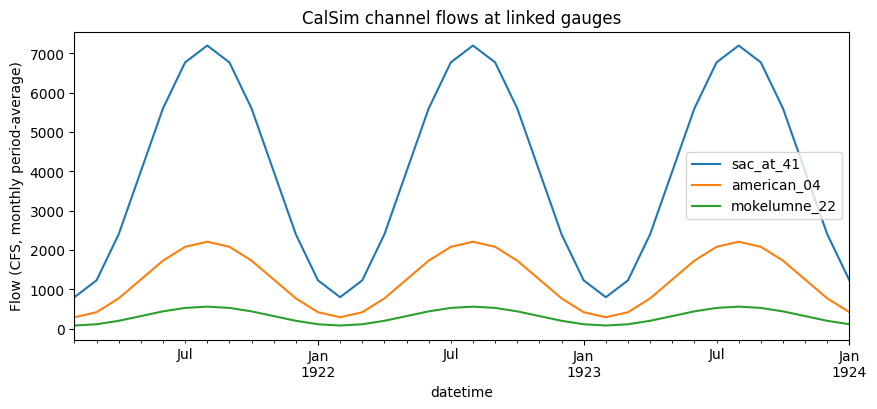

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
cfs.plot(ax=ax)
ax.set_ylabel("Flow (CFS, monthly period-average)")
ax.set_title("CalSim channel flows at linked gauges")
plt.show()

## Wiring CalSim flows into an IWFM calibration

The end game (notebooks 08–10): CalSim channel flow becomes the
*observed* record for an IWFM stream gauge. Because both sides use
end-of-period stamps, monthly alignment is a plain merge:

1. extract IWFM simulated gauge flows (`stream_hydrograph_series`,
   notebook 08) and resample to month-end means
   (`resample_month_end` honors the 24:00 convention)
2. take the CalSim series above as observations
3. pair with `match_sim_to_obs`, score with `residual_stats`, name with
   `encode_obs_names("stf", ...)`, and hand to `PestSetup`

In [10]:
from iwfm_io.pest import encode_obs_names, match_sim_to_obs, residual_stats

# stand-in for IWFM simulated monthly flows at the same gauges
rng = np.random.default_rng(5)
sim = cfs * (1.0 + rng.normal(0, 0.08, cfs.shape))

obs_long = cfs.reset_index(names="datetime").melt(
    id_vars="datetime", var_name="site", value_name="value")

paired = match_sim_to_obs(sim, obs_long)
paired["obsnme"] = encode_obs_names("stf", paired["site"], paired["datetime"])
residual_stats(paired, by="site")[["n", "mean_res", "rmse", "nse", "kge"]]

,n,mean_res,rmse,nse,kge
site,,,,,
american_04,36,-17.474579,116.873758,0.970357,0.950825
mokelumne_22,36,10.262820,26.351817,0.975888,0.961224
sac_at_41,36,107.568907,317.487625,0.980313,0.960199


## Working with real CalSim files — field notes

- **condensed paths read whole records**: real DV files split long
  series into decade blocks; `read_dss_timeseries` stitches them
- **`cpart="CHANNEL"` is usually required**: the same arc name appears
  under multiple C parts in production files
- **`fpart=`** disambiguates when one file carries several studies
  (`L2020A` vs `L2035A`)
- **units guard**: `units="taf"` refuses non-CFS records instead of
  silently converting stage or storage
- the module was validated against a production CalSim3 + C2VSimCG
  calibration's DV file

In [11]:
import shutil

shutil.rmtree(WORK, ignore_errors=True)
print("workspace removed")

workspace removed
